---
# Depression Prediction Using Machine Learning: Findings from NHANES 2021–2023

**Module:** Machine Learning (Module 5)

**Dataset:** NHANES 2021–2023

**Models:** Logistic Regression & Random Forest  

**Outcome:** PHQ-9 ≥ 10 (clinically significant depressive symptoms)



---


---
## 1. Setup & Dependencies



In [ ]:
# All Imports

import pandas as pd
import numpy as np
import requests
import os
import warnings
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns


from scipy import stats
from scipy.stats import norm
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, average_precision_score
)
from sklearn.inspection import permutation_importance

warnings.filterwarnings('ignore')
np.random.seed(42)

# Print versions for reproducibility log
print("Library versions")
print(f"  pandas       {pd.__version__}")
print(f"  numpy        {np.__version__}")
import sklearn; print(f"  scikit-learn {sklearn.__version__}")
import scipy;   print(f"  scipy        {scipy.__version__}")
import matplotlib; print(f"  matplotlib   {matplotlib.__version__}")
import seaborn; print(f"  seaborn      {seaborn.__version__}")


Library versions
  pandas       2.2.2
  numpy        2.0.2
  scikit-learn 1.6.1
  scipy        1.16.3
  matplotlib   3.10.0
  seaborn      0.13.2


---
## 2. Data Loading & Preparation


In [ ]:
# File registry
BASE_URL = "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/"

FILES = {
    "DEMO_L":   "DEMO_L.XPT",    # Demographics
    "DPQ_L":    "DPQ_L.XPT",     # PHQ-9 (outcome)
    "BMX_L":    "BMX_L.XPT",     # BMI, waist circumference
    "SLQ_L":    "SLQ_L.XPT",     # Sleep
    "PAQ_L":    "PAQ_L.XPT",     # Physical activity
    "SMQ_L":    "SMQ_L.XPT",     # Smoking
    "SMQRTU_L": "SMQRTU_L.XPT",  # E-cigarette use
    "ALQ_L":    "ALQ_L.XPT",     # Alcohol
    "BPQ_L":    "BPQ_L.XPT",     # Hypertension, cholesterol
    "DIQ_L":    "DIQ_L.XPT",     # Diabetes
    "MCQ_L":    "MCQ_L.XPT",     # Chronic conditions
    "KIQ_U_L":  "KIQ_U_L.XPT",  # Kidney failure
    "OCQ_L":    "OCQ_L.XPT",     # Employment
    "HIQ_L":    "HIQ_L.XPT",     # Health insurance
    "FSQ_L":    "FSQ_L.XPT",     # Food security
}

# Download and load all NHANES modules

dfs = {}
for name, file in FILES.items():
    try:
        dfs[name] = pd.read_sas(BASE_URL + file, format='xport', encoding='utf-8')
        print(f"{file}: {dfs[name].shape[0]:,} rows")
    except Exception as e:
        print(f"FAILED: {file} — {e}")


DEMO_L.XPT: 11,933 rows
DPQ_L.XPT: 6,337 rows
BMX_L.XPT: 8,860 rows
SLQ_L.XPT: 8,501 rows
PAQ_L.XPT: 8,153 rows
SMQ_L.XPT: 9,015 rows
SMQRTU_L.XPT: 7,199 rows
ALQ_L.XPT: 6,337 rows
BPQ_L.XPT: 8,501 rows
DIQ_L.XPT: 11,744 rows
MCQ_L.XPT: 11,744 rows
KIQ_U_L.XPT: 7,809 rows
OCQ_L.XPT: 8,501 rows
HIQ_L.XPT: 11,933 rows
FSQ_L.XPT: 11,933 rows


In [ ]:
#  Define variables to extract from each module

COLUMNS_TO_KEEP = {
    "DEMO_L": [
        "SEQN",      # Participant ID — merge key
        "RIDAGEYR",  # Age
        "RIAGENDR",  # Sex
        "RIDRETH3",  # Race/ethnicity — fairness variable only
        "DMDEDUC2",  # Education
        "DMDMARTZ",  # Marital status
        "DMDHHSIZ",  # Household size
        "INDFMPIR",  # Income-to-poverty ratio
    ],
    "DPQ_L": [
        "SEQN",
        "DPQ010", "DPQ020", "DPQ030", "DPQ040", "DPQ050",  # PHQ-9 items 1-5
        "DPQ060", "DPQ070", "DPQ080", "DPQ090",             # PHQ-9 items 6-9
    ],
    "BMX_L":    ["SEQN", "BMXBMI", "BMXWAIST"],             # BMI, waist circumference
    "SLQ_L":    ["SEQN", "SLD012", "SLD013"],                # Weekday/weekend sleep hours
    "PAQ_L":    ["SEQN", "PAD680", "PAD790Q", "PAD790U", "PAD800"],  # Sedentary + LTPA derivation
    "SMQ_L":    ["SEQN", "SMQ020", "SMQ040"],                # Smoking history + current use
    "SMQRTU_L": ["SEQN", "SMQ846"],                          # E-cigarette use
    "ALQ_L":    ["SEQN", "ALQ111", "ALQ121", "ALQ151"],      # Alcohol use
    "BPQ_L":    ["SEQN", "BPQ020", "BPQ080"],                # Hypertension, cholesterol
    "DIQ_L":    ["SEQN", "DIQ010"],                          # Diabetes
    "MCQ_L":    ["SEQN", "MCQ010", "MCQ053", "MCQ160A", "MCQ160B",
                          "MCQ160E", "MCQ160F", "MCQ160L", "MCQ160M",
                          "MCQ160P", "MCQ220"],               # Chronic conditions
    "KIQ_U_L":  ["SEQN", "KIQ022"],                         # Kidney failure
    "OCQ_L":    ["SEQN", "OCD150"],                          # Employment status
    "HIQ_L":    ["SEQN", "HIQ011", "HIQ210"],                # Health insurance
    "FSQ_L":    ["SEQN", "FSDAD", "FSQ012"],                 # Food security, SNAP
}

# Subset each module to required variables only
trimmed = {}
for key, cols in COLUMNS_TO_KEEP.items():
    available = [c for c in cols if c in dfs[key].columns]
    if set(cols) - set(available):
        print(f"WARNING: {key} missing {set(cols) - set(available)}")
    trimmed[key] = dfs[key][available].copy()

# Left join on DEMO_L — NaN for any module the participant didn't complete
df = trimmed["DEMO_L"]
for key in list(COLUMNS_TO_KEEP.keys())[1:]:
    df = df.merge(trimmed[key], on="SEQN", how="left")

print(f"Merged: {df.shape[0]:,} rows x {df.shape[1]} cols")

Merged: 11,933 rows x 50 cols


In [ ]:
# Replace SAS floating point artefact with 0
df = df.replace(5.397605346934028e-79, 0)

# Restrict to adults 18+
df = df[df["RIDAGEYR"] >= 18].copy()

# Recode 7=Refused, 9=Don't know to NaN before dropping
phq_items = ["DPQ010","DPQ020","DPQ030","DPQ040","DPQ050",
             "DPQ060","DPQ070","DPQ080","DPQ090"]
for item in phq_items:
    df[item] = df[item].replace({7: np.nan, 9: np.nan})

# Drop incomplete PHQ-9 responses — partial scores cannot be summed
df = df.dropna(subset=phq_items).copy()

# PHQ-9 total ≥10 = clinically significant depression (Kroenke et al., 2001)
df["PHQ9_total"] = df[phq_items].sum(axis=1)
df["depressed"]  = (df["PHQ9_total"] >= 10).astype(int)

# printing total no. and depressed no. and %
print(f"N = {len(df):,} | Depressed: {df['depressed'].sum():,} ({100*df['depressed'].mean():.1f}%)")

# Save checkpoint, allows subsequent sections to run independently
df.to_csv("nhanes_merged_raw.csv", index=False)

N = 5,455 | Depressed: 723 (13.3%)


---
## 3. Feature Engineering


In [ ]:
# load checkpoint from data preparation stage
df = pd.read_csv("nhanes_merged_raw.csv")

# NHANES codes: 1=Yes, 2=No, 7=Refused, 9=Don't know → recoded to 1/0/NaN
binary_vars = {
    "HIQ011":  "health_insurance",
    "HIQ210":  "uninsured_past_year",
    "FSQ012":  "snap_receipt",
    "ALQ151":  "heavy_drinking_hx",
    "BPQ020":  "hypertension",
    "BPQ080":  "high_cholesterol",
    "MCQ010":  "asthma",
    "MCQ053":  "anaemia_treatment",
    "MCQ160A": "arthritis",
    "MCQ160B": "heart_failure",
    "MCQ160E": "heart_attack",
    "MCQ160F": "stroke",
    "MCQ160L": "liver_condition",
    "MCQ160M": "thyroid_problem",
    "MCQ160P": "copd",
    "MCQ220":  "cancer",
    "KIQ022":  "kidney_failure",
}

for raw_col, new_col in binary_vars.items():
    if raw_col in df.columns:
        df[new_col] = df[raw_col].map({1: 1, 2: 0})

# Borderline diabetes recoded as 0 — not a confirmed diagnosis
df["diabetes"] = df["DIQ010"].map({1: 1, 2: 0, 3: 0})

In [ ]:
#  Deriving sleeping variables
# Weekday (SLD012) and weekend (SLD013) sleep hours are each categorised as: short  = < 6 hours, normal = 6–8 hours, long   = > 8 hours

def categorise_sleep(hours):
    if pd.isna(hours):
        return np.nan
    elif hours < 6:
        return "short"
    elif hours <= 8:
        return "normal"
    else:
        return "long"

df["sleep_weekday"] = df["SLD012"].apply(categorise_sleep)
df["sleep_weekend"] = df["SLD013"].apply(categorise_sleep)

In [ ]:
# Deriving Sedentary behaviour categories: PAD680: self-reported sedentary minutes per day, categorised as:
#   low       = 0–300 min/day   (0–5 hours)
#   moderate  = 301–600 min/day (5–10 hours)
#   high      = 601–900 min/day (10–15 hours)
#   very high = > 900 min/day   (>15 hours)

def categorise_sedentary(mins):
    if pd.isna(mins):
        return np.nan
    elif mins <= 300:
        return "low"
    elif mins <= 600:
        return "moderate"
    elif mins <= 900:
        return "high"
    else:
        return "very_high"

df["sedentary_cat"] = df["PAD680"].apply(categorise_sedentary)

In [ ]:
# Derive weekly Lesiure time physical activity (mins) from frequency, unit, and session duration

# Convert activity frequency to weekly equivalent using unit conversion factors
unit_to_weekly = {"D": 7, "W": 1, "M": 1/4.33, "Y": 1/52}

def derive_ltpa(row):
    freq = row.get("PAD790Q") # frequency value
    unit = str(row.get("PAD790U", "")).strip().upper() # D/W/M/Y
    dur  = row.get("PAD800") # session duration (mins)
    if pd.isna(freq) or pd.isna(dur) or unit not in unit_to_weekly:
        return np.nan
    return freq * unit_to_weekly[unit] * dur # weekly mins

df["ltpa_weekly_mins"] = df.apply(derive_ltpa, axis=1)

# Classify per WHO guidelines
def classify_ltpa(mins):
    if pd.isna(mins):
        return np.nan
    elif mins == 0:
        return "inactive"
    elif mins < 150:
        return "insufficiently_active"
    else:
        return "sufficiently_active"

df["ltpa_cat"] = df["ltpa_weekly_mins"].apply(classify_ltpa)

In [ ]:
# Deriving Smoking status Variable
# Derived from:
#   SMQ020: smoked ≥100 cigarettes in lifetime (1=Yes, 2=No)
#   SMQ040: current smoking frequency (1=every day, 2=some days, 3=not at all)
# Categories: never_smoker, ex_smoker, current_smoker

def derive_smoking(row):
    smoked_100 = row.get("SMQ020")
    current    = row.get("SMQ040")
    if smoked_100 == 2:
        return "never_smoker"
    elif smoked_100 == 1:
        if current in [1, 2]:
            return "current_smoker"
        elif current == 3:
            return "ex_smoker"
    return np.nan

df["smoking_status"] = df.apply(derive_smoking, axis=1)

# Deriving Smoking / e-cigarette combined category

def derive_smoking_ecig(row):
    cig  = row.get("smoking_status")
    ecig = row.get("SMQ846")
    if cig == "current_smoker" and ecig == 1:
        return "dual_user"
    elif cig == "current_smoker":
        return "cigarette_only"
    elif ecig == 1:
        return "ecig_only"
    elif cig in ["never_smoker", "ex_smoker"]:
        return "non_smoker"
    return np.nan

df["smoking_ecig_cat"] = df.apply(derive_smoking_ecig, axis=1)

In [ ]:
# Deriving Alcohol use category
#   ALQ111: ever had a drink (1=Yes, 2=No)
#   ALQ121: past-year drinking frequency
#     0=never, 1=every day, 2=nearly every day, 3=3–4/week, 4=2/week,
#     5=1/week, 6=2–3/month, 7=1/month, 8=7–11/year, 9=3–6/year, 10=1–2/year
# Categories:
#   never_drinker, former_drinker, infrequent (9–10), moderate (6–8), frequent (1–5)

def derive_alcohol(row):
    ever = row.get("ALQ111")
    freq = row.get("ALQ121")
    if ever == 2:
        return "never_drinker"
    if ever == 1:
        if pd.isna(freq) or freq == 0:
            return "former_drinker"
        elif freq in [9, 10]:
            return "infrequent"    # few times a year
        elif freq in [6, 7, 8]:
            return "moderate"      # monthly
        elif freq in [1, 2, 3, 4, 5]:
            return "frequent"      # weekly or more
    return np.nan

df["alcohol_cat"] = df.apply(derive_alcohol, axis=1)

In [ ]:
# Rename remaining raw variables to readable names
rename_map = {
    "RIDAGEYR": "age",
    "RIAGENDR": "sex",
    "DMDEDUC2": "education",
    "DMDMARTZ": "marital_status",
    "DMDHHSIZ": "household_size",
    "INDFMPIR": "income_poverty_ratio",
    "BMXBMI":   "bmi",
    "BMXWAIST": "waist_cm",
    "OCD150":   "employment_status",
    "FSDAD":    "food_security",
}
df = df.rename(columns=rename_map)

# Recode missing codes for ordinal/continuous variables
for col in ["education", "marital_status", "employment_status", "food_security"]:
    if col in df.columns:
        df[col] = df[col].replace({7: np.nan, 9: np.nan, 77: np.nan, 99: np.nan})

# Sex: 1=Male → 0, 2=Female → 1
df["sex"] = df["sex"].map({1: 0, 2: 1})

# Save checkpoint for feature selection stage
df.to_csv("nhanes_engineered.csv", index=False)

---
## 4. Exploratory Data Analysis



In [ ]:
# Creating descriptive statistics table


df = pd.read_csv("nhanes_engineered.csv")
df = df.apply(pd.to_numeric, errors='ignore') # ensure numeric columns are correctly typed

dep   = df[df["depressed"] == 1] # depressed sub group
nodep = df[df["depressed"] == 0] # non-depressed sub-group
n_dep   = len(dep)
n_nodep = len(nodep)
n_total = len(df)

rows = [] # store one row per variable for final table

def add_continuous(col, label):
    if col not in df.columns:
        return
    x = dep[col].dropna()
    y = nodep[col].dropna()
    a = df[col].dropna()

    # Test normality on sample ≤5000 (Shapiro-Wilk limit)
    _, p_norm = stats.shapiro(a.sample(min(5000, len(a)), random_state=42))

    if p_norm > 0.05:
        _, p_val = stats.ttest_ind(x, y, nan_policy="omit")
        fmt = lambda s: f"{s.mean():.1f} ± {s.std():.1f}" # normal — t-test and mean ± SD
    else:     # non-normal — Mann-Whitney U and median (IQR)
        _, p_val = stats.mannwhitneyu(x, y, alternative="two-sided")
        fmt = lambda s: f"{s.median():.1f} ({s.quantile(0.25):.1f}–{s.quantile(0.75):.1f})"

    rows.append({
        "Variable":                       label,
        f"Overall (N={n_total:,})":       fmt(a),
        f"Non-depressed (N={n_nodep:,})": fmt(y),
        f"Depressed (N={n_dep:,})":       fmt(x),
        "p-value": "<0.001" if p_val < 0.001 else f"{p_val:.3f}"
    })

def add_categorical(col, label, value_labels=None):
    if col not in df.columns:
        return

    # Chi-square for group differences
    ct = pd.crosstab(df[col], df["depressed"])
    _, p_val, _, _ = stats.chi2_contingency(ct)
    p_str = "<0.001" if p_val < 0.001 else f"{p_val:.3f}"

    # Header row
    rows.append({"Variable": f"{label}, n (%)",
                 f"Overall (N={n_total:,})": "",
                 f"Non-depressed (N={n_nodep:,})": "",
                 f"Depressed (N={n_dep:,})": "",
                 "p-value": p_str})

    # One row per category using valid n as denominator
    for cat in sorted(df[col].dropna().unique()):
        lbl   = value_labels.get(cat, str(cat)) if value_labels else str(cat)
        n_a   = (df[col] == cat).sum();   denom_a = df[col].count()
        n_d   = (dep[col] == cat).sum();  denom_d = dep[col].count()
        n_nd  = (nodep[col] == cat).sum(); denom_nd = nodep[col].count()
        rows.append({
            "Variable":                       f"  {lbl}",
            f"Overall (N={n_total:,})":       f"{n_a} ({100*n_a/denom_a:.1f}%)",
            f"Non-depressed (N={n_nodep:,})": f"{n_nd} ({100*n_nd/denom_nd:.1f}%)",
            f"Depressed (N={n_dep:,})":       f"{n_d} ({100*n_d/denom_d:.1f}%)",
            "p-value": ""
        })

# Binary 0/1 variables — single n (%) row with chi-square test
def add_binary(col, label):
    if col not in df.columns:
        return
    ct = pd.crosstab(df[col], df["depressed"])
    _, p_val, _, _ = stats.chi2_contingency(ct)

    # Use valid n as denominator
    rows.append({
        "Variable":                       f"{label}, n (%)",
        f"Overall (N={n_total:,})":       f"{df[col].sum():.0f} ({100*df[col].sum()/df[col].count():.1f}%)",
        f"Non-depressed (N={n_nodep:,})": f"{nodep[col].sum():.0f} ({100*nodep[col].sum()/nodep[col].count():.1f}%)",
        f"Depressed (N={n_dep:,})":       f"{dep[col].sum():.0f} ({100*dep[col].sum()/dep[col].count():.1f}%)",
        "p-value": "<0.001" if p_val < 0.001 else f"{p_val:.3f}"
    })

# Continuous Variables
add_continuous("age",                  "Age, years")
add_continuous("bmi",                  "BMI, kg/m²")
add_continuous("waist_cm",             "Waist circumference, cm")
add_continuous("household_size",       "Household size")
add_continuous("income_poverty_ratio", "Income-to-poverty ratio")

# Categorical Variables
add_categorical("sex", "Sex", {0: "Male", 1: "Female"})

add_categorical("education", "Education level", {
    1: "Less than 9th grade", 2: "9–11th grade",
    3: "High school graduate", 4: "Some college or AA degree",
    5: "College graduate or above"
})

add_categorical("marital_status", "Marital status", {
    1: "Married/Living with partner",
    2: "Widowed/Divorced/Separated",
    3: "Never married"
})

add_categorical("employment_status", "Employment status", {
    1: "Working", 2: "With job but not at work",
    3: "Looking for work", 4: "Not working"
})

add_categorical("food_security", "Food security", {
    1: "Full food security", 2: "Marginal food security",
    3: "Low food security",  4: "Very low food security"
})

add_categorical("sleep_weekday", "Weekday sleep",
    {"short": "Short (<6 hrs)", "normal": "Normal (6–8 hrs)", "long": "Long (>8 hrs)"})

add_categorical("sleep_weekend", "Weekend sleep",
    {"short": "Short (<6 hrs)", "normal": "Normal (6–8 hrs)", "long": "Long (>8 hrs)"})

add_categorical("sedentary_cat", "Sedentary behaviour", {
    "low": "Low (0–5 hrs/day)", "moderate": "Moderate (5–10 hrs/day)",
    "high": "High (10–15 hrs/day)", "very_high": "Very high (>15 hrs/day)"
})

add_categorical("ltpa_cat", "Physical activity (LTPA)", {
    "inactive": "Inactive", "insufficiently_active": "Insufficiently active",
    "sufficiently_active": "Sufficiently active"
})

add_categorical("smoking_status", "Smoking status", {
    "never_smoker": "Never smoker", "ex_smoker": "Ex-smoker",
    "current_smoker": "Current smoker"
})

add_categorical("smoking_ecig_cat", "Smoking/e-cigarette use", {
    "non_smoker": "Non-smoker", "cigarette_only": "Cigarette only",
    "ecig_only": "E-cigarette only", "dual_user": "Dual user"
})

add_categorical("alcohol_cat", "Alcohol use", {
    "never_drinker": "Never drinker", "former_drinker": "Former drinker",
    "infrequent": "Infrequent", "moderate": "Moderate", "frequent": "Frequent"
})

#  Binary Variables
for col, label in [
    ("health_insurance",    "Health insurance"),
    ("uninsured_past_year", "Uninsured past year"),
    ("snap_receipt",        "SNAP receipt"),
    ("hypertension",        "Hypertension"),
    ("high_cholesterol",    "High cholesterol"),
    ("diabetes",            "Diabetes"),
    ("asthma",              "Asthma"),
    ("anaemia_treatment",   "Anaemia treatment"),
    ("arthritis",           "Arthritis"),
    ("heart_failure",       "Heart failure"),
    ("heart_attack",        "Heart attack"),
    ("stroke",              "Stroke"),
    ("liver_condition",     "Liver condition"),
    ("thyroid_problem",     "Thyroid problem"),
    ("copd",                "COPD"),
    ("cancer",              "Cancer"),
    ("kidney_failure",      "Kidney failure"),
    ("heavy_drinking_hx",   "Heavy drinking history"),
]:
    add_binary(col, label)

# Output table
table1 = pd.DataFrame(rows)
print(table1.to_string(index=False))
table1.to_csv("table1_descriptive_stats.csv", index=False)

                       Variable Overall (N=5,455) Non-depressed (N=4,732)  Depressed (N=723) p-value
                     Age, years  56.0 (37.0–67.0)        57.0 (38.0–68.0)   46.0 (29.0–62.0)  <0.001
                     BMI, kg/m²  28.3 (24.5–33.4)        28.2 (24.5–33.0)   29.5 (24.8–35.7)  <0.001
        Waist circumference, cm 99.1 (88.2–111.0)       98.9 (88.3–110.4) 101.5 (88.0–115.5)   0.002
                 Household size     2.0 (2.0–3.0)           2.0 (2.0–3.0)      2.0 (1.0–3.0)   0.254
        Income-to-poverty ratio     2.9 (1.5–5.0)           3.2 (1.6–5.0)      1.8 (1.0–3.2)  <0.001
                     Sex, n (%)                                                               <0.001
                           Male      2487 (45.6%)            2224 (47.0%)        263 (36.4%)        
                         Female      2968 (54.4%)            2508 (53.0%)        460 (63.6%)        
         Education level, n (%)                                                            

---
## 5. Feature Selection


In [ ]:

df = pd.read_csv("nhanes_engineered.csv")
df = df.apply(pd.to_numeric, errors='ignore')

# Defining candidate feature set
FEATURE_COLS = [
    "age", "sex", "education", "marital_status", "household_size",
    "income_poverty_ratio", "employment_status", "health_insurance",
    "uninsured_past_year", "food_security", "snap_receipt",
    "bmi", "waist_cm",
    "sleep_weekday", "sleep_weekend",
    "sedentary_cat", "ltpa_cat",
    "smoking_status", "smoking_ecig_cat", "alcohol_cat", "heavy_drinking_hx",
    "hypertension", "high_cholesterol", "diabetes", "asthma",
    "anaemia_treatment", "arthritis", "heart_failure", "heart_attack",
    "stroke", "liver_condition", "thyroid_problem", "copd", "cancer",
    "kidney_failure",
]

FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns] # guard against missing columns
TARGET       = "depressed"
FAIRNESS     = [ "sex", "age"] # retained for subgroup analysis

# print no. of candidate features
print(f"Candidate features: {len(FEATURE_COLS)}")

Candidate features: 35


In [ ]:
# Train / test split (before any feature selection) to prevent data leakage

X = df[FEATURE_COLS].copy()
y = df[TARGET].copy()
fairness_data = df[FAIRNESS].copy() # kept seperate for sub-group analysis

# 80/20 stratified split to preserve class balance across sets.
X_train_raw, X_test_raw, y_train, y_test, fair_train, fair_test = train_test_split(
    X, y, fairness_data,
    test_size=0.2,
    stratify=y, # ensures same class ratio in train and test
    random_state=42 # for reproducability
)

# print training and test participants out
print(f"Training : {X_train_raw.shape[0]:,} participants ({y_train.sum():,} depressed, {100*y_train.mean():.1f}%)")
print(f"Test     : {X_test_raw.shape[0]:,} participants ({y_test.sum():,} depressed, {100*y_test.mean():.1f}%)")

Training : 4,364 participants (578 depressed, 13.2%)
Test     : 1,091 participants (145 depressed, 13.3%)


In [ ]:
# Stage 1: Remove high-missingness variables (> 50%)

# calcualting missingness rate for each feature in training set
missingness = X_train_raw.isnull().mean()

# Identify features exceeding 50% missing threshold
high_missing = missingness[missingness > 0.5].index.tolist()

print(f"Stage 1 — removed ({len(high_missing)} variables >50% missing):")
for col in high_missing:
    print(f"  {col}: {missingness[col]*100:.1f}%")

# Remove high-missingness features from both train and test sets
X_train_s1 = X_train_raw.drop(columns=high_missing)
X_test_s1  = X_test_raw.drop(columns=high_missing)
print(f"Features remaining: {X_train_s1.shape[1]}")

Stage 1 — removed (1 variables >50% missing):
  snap_receipt: 64.3%
Features remaining: 34


In [ ]:
# define nominal categorical variables for one-hot encoding

nominal_cats = [
    "marital_status", "employment_status", "sleep_weekday", "sleep_weekend",
    "sedentary_cat", "ltpa_cat", "smoking_status", "smoking_ecig_cat", "alcohol_cat",
]
nominal_cats = [c for c in nominal_cats if c in X_train_s1.columns] # guard against missing columns

# Set clinically meaningful reference categories before encoding- - first in list will be dropped by drop_first=True. Reference = healthy/neutral baseline (e.g. normal sleep, never smoker, sufficiently active)
category_orders = {
    "sleep_weekday":    ["normal", "short", "long"],
    "sleep_weekend":    ["normal", "short", "long"],
    "sedentary_cat":    ["low", "moderate", "high", "very_high"],
    "ltpa_cat":         ["sufficiently_active", "insufficiently_active", "inactive"],
    "smoking_status":   ["never_smoker", "ex_smoker", "current_smoker"],
    "smoking_ecig_cat": ["non_smoker", "cigarette_only", "ecig_only", "dual_user"],
    "alcohol_cat":      ["never_drinker", "infrequent", "moderate", "frequent", "former_drinker"],
    "marital_status":   [1.0, 2.0, 3.0],
    "employment_status":[1.0, 2.0, 3.0, 4.0],
}

# Apply category ordering to training and test sets
for col, order in category_orders.items():
    if col in X_train_s1.columns:
        X_train_s1[col] = pd.Categorical(X_train_s1[col], categories=order)
        X_test_s1[col]  = pd.Categorical(X_test_s1[col],  categories=order)

# one hot encode nomial variables
# drop_first=True drops reference category per variable to avoid dummy variable trap
X_train_enc = pd.get_dummies(X_train_s1, columns=nominal_cats, drop_first=True)
X_test_enc  = pd.get_dummies(X_test_s1,  columns=nominal_cats, drop_first=True)

# Align test set columns to training set — fills any missing dummy columns with 0
X_train_enc, X_test_enc = X_train_enc.align(X_test_enc, join="left", axis=1, fill_value=0)

# Median Imputation - only on traning set
train_medians = X_train_enc.median()
X_train_enc   = X_train_enc.fillna(train_medians)
X_test_enc    = X_test_enc.fillna(train_medians)

# Stage 2: remove highly correlated features (r > 0.80)
corr_matrix = X_train_enc.corr().abs()
# Upper triangle only — avoids counting each pair twice
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop_corr = [col for col in upper.columns if any(upper[col] > 0.80)]

print(f"Stage 2 — removed ({len(to_drop_corr)} variables r > 0.80):")
for col in to_drop_corr:
    partner = upper[col][upper[col] > 0.80].idxmax()
    print(f"  {col} (r={upper[col].max():.2f} with {partner})")

# Remove correlated features from both sets
X_train_s2 = X_train_enc.drop(columns=to_drop_corr)
X_test_s2  = X_test_enc.drop(columns=to_drop_corr)
print(f"Features remaining: {X_train_s2.shape[1]}")

Stage 2 — removed (2 variables r > 0.80):
  waist_cm (r=0.87 with bmi)
  smoking_ecig_cat_cigarette_only (r=0.93 with smoking_status_current_smoker)
Features remaining: 46


In [ ]:
# Stage 3: Logistic LASSO — L1 penalty applied to logistic regression

# Standardise features before LASSO
# fit_transform on training set only; transform applied to test set to prevent leakage
scaler_lasso = StandardScaler()
X_train_scaled = scaler_lasso.fit_transform(X_train_s2)
X_test_scaled  = scaler_lasso.transform(X_test_s2)

# Fit logistic LASSO with C selected by 5-fold CV optimising AUC
# Lower C = stronger regularisation = more features shrunk to zero
lasso_lr = LogisticRegressionCV(
    penalty="l1",
    solver="liblinear",
    cv=5,
    scoring="roc_auc", # optimise for discrimination given class imbalance
    random_state=42,
    max_iter=5000
)
lasso_lr.fit(X_train_scaled, y_train)

# Identify retained features — non-zero coefficients after penalisation
lasso_mask        = lasso_lr.coef_[0] != 0
selected_features = X_train_s2.columns[lasso_mask].tolist()
dropped_features  = X_train_s2.columns[~lasso_mask].tolist()

print(f"Stage 3 — Logistic LASSO (C={lasso_lr.C_[0]:.4f})")
print(f"  Retained : {len(selected_features)}")
print(f"  Dropped  : {len(dropped_features)}")
print(f"\nDropped features: {dropped_features}")
print(f"\nSelected features: {selected_features}")

# Subset train and test to selected features only
X_train_final = X_train_s2[selected_features]
X_test_final  = X_test_s2[selected_features]

# Save selected features for reference
pd.Series(selected_features).to_csv("selected_features.csv", index=False)

Stage 3 — Logistic LASSO (C=0.0464)
  Retained : 29
  Dropped  : 17

Dropped features: ['education', 'uninsured_past_year', 'hypertension', 'high_cholesterol', 'cancer', 'kidney_failure', 'marital_status_2.0', 'employment_status_2.0', 'sleep_weekday_long', 'sleep_weekend_long', 'sedentary_cat_high', 'ltpa_cat_insufficiently_active', 'ltpa_cat_inactive', 'smoking_status_ex_smoker', 'alcohol_cat_infrequent', 'alcohol_cat_moderate', 'alcohol_cat_former_drinker']

Selected features: ['age', 'sex', 'household_size', 'income_poverty_ratio', 'health_insurance', 'food_security', 'bmi', 'heavy_drinking_hx', 'diabetes', 'asthma', 'anaemia_treatment', 'arthritis', 'heart_failure', 'heart_attack', 'stroke', 'liver_condition', 'thyroid_problem', 'copd', 'marital_status_3.0', 'employment_status_3.0', 'employment_status_4.0', 'sleep_weekday_short', 'sleep_weekend_short', 'sedentary_cat_moderate', 'sedentary_cat_very_high', 'smoking_status_current_smoker', 'smoking_ecig_cat_ecig_only', 'smoking_ecig_c

---
## 6. Model Development

In [ ]:
# Final standardisation for model fitting

#New scaler fitted on LASSO-selected features only
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_final)
X_test_sc  = scaler.transform(X_test_final)


# Convert back to DataFrame to preserve feature names for interpretation
X_train_sc = pd.DataFrame(X_train_sc, columns=selected_features)
X_test_sc  = pd.DataFrame(X_test_sc,  columns=selected_features)

print(f"Training set : {X_train_sc.shape}")
print(f"Test set     : {X_test_sc.shape}")

Training set : (4364, 29)
Test set     : (1091, 29)


In [ ]:
# Logistic Regression

# class_weight='balanced' penalises minority class misclassification proportionally
# C controls regularisation strength — tuned via 5-fold CV optimising AUC

lr_grid = GridSearchCV(
    LogisticRegression(class_weight="balanced", max_iter=5000, random_state=42),
    param_grid={"C": [0.001, 0.01, 0.1, 1, 10, 100]}, # range of regularisation stregnths
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="roc_auc", # optimise for discrimination given class imbalance
    n_jobs=-1 # use all available CPU scores
)
lr_grid.fit(X_train_sc, y_train)
best_lr = lr_grid.best_estimator_  # retain best model for evaluation

print(f"Logistic Regression — best C: {lr_grid.best_params_['C']}, CV AUC: {lr_grid.best_score_:.4f}")


Logistic Regression — best C: 0.01, CV AUC: 0.7679


In [ ]:
# Random Forest
# class_weight='balanced_subsample' applies weights at each bootstrap sample - recommended for tree-based models

rf_grid = GridSearchCV(
    RandomForestClassifier(class_weight="balanced_subsample", random_state=42),
    param_grid={
        "n_estimators":     [100, 200], # number of trees
        "max_depth":        [None, 10, 20], # maximum tree depth
        "min_samples_leaf": [1, 5, 10], # min samples required at leaf node
    },
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="roc_auc",
    n_jobs=-1
)
rf_grid.fit(X_train_sc, y_train)
best_rf = rf_grid.best_estimator_ # retain best model for evaluation

print(f"Random Forest — best params: {rf_grid.best_params_}, CV AUC: {rf_grid.best_score_:.4f}")


Random Forest — best params: {'max_depth': 10, 'min_samples_leaf': 10, 'n_estimators': 200}, CV AUC: 0.7582


In [ ]:
# Cross-validation stability
# evaluated how consistenly model performs across 5-folds
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lr_cv = cross_val_score(best_lr, X_train_sc, y_train, cv=cv, scoring="roc_auc") # cross val score LR
rf_cv = cross_val_score(best_rf, X_train_sc, y_train, cv=cv, scoring="roc_auc") # cross val score RF

print(f"\n5-fold CV AUC (training set):")
print(f"  Logistic Regression : {lr_cv.mean():.4f} ± {lr_cv.std():.4f}")
print(f"  Random Forest       : {rf_cv.mean():.4f} ± {rf_cv.std():.4f}")


5-fold CV AUC (training set):
  Logistic Regression : 0.7679 ± 0.0223
  Random Forest       : 0.7582 ± 0.0180


---
## 7. Model Evaluation


In [ ]:
#   Test set metrics

# returns metric dict, predicted labels and predicted probabilities
def evaluate_model(model, X_test, y_test, model_name):
    y_pred  = model.predict(X_test) # binary predictions (0/1)
    y_proba = model.predict_proba(X_test)[:, 1] # predicted probability of depression

    return {
        "Model":       model_name,
        "AUC":         round(roc_auc_score(y_test, y_proba), 4),
        "PR-AUC":      round(average_precision_score(y_test, y_proba), 4),
        "Accuracy":    round(accuracy_score(y_test, y_pred), 4),
        "Sensitivity": round(recall_score(y_test, y_pred), 4),
        "Specificity": round(recall_score(y_test, y_pred, pos_label=0), 4),
        "Precision":   round(precision_score(y_test, y_pred, zero_division=0), 4),
        "F1":          round(f1_score(y_test, y_pred, zero_division=0), 4),
    }, y_pred, y_proba

lr_metrics, lr_pred, lr_proba = evaluate_model(best_lr, X_test_sc, y_test, "Logistic Regression")
rf_metrics, rf_pred, rf_proba = evaluate_model(best_rf, X_test_sc, y_test, "Random Forest")

# display results table
results = pd.DataFrame([lr_metrics, rf_metrics]).set_index("Model")
print("Test set performance:")
print(results.to_string())



Test set performance:
                        AUC  PR-AUC  Accuracy  Sensitivity  Specificity  Precision      F1
Model                                                                                     
Logistic Regression  0.7582  0.3364    0.7177       0.6276       0.7315     0.2638  0.3714
Random Forest        0.7598  0.3528    0.7745       0.5310       0.8118     0.3020  0.3850


In [ ]:
#   Bootstrap CIs (1000 resamples)
def bootstrap_ci(model, X_test, y_test, n_boot=1000, seed=42):
    rng   = np.random.RandomState(seed)
    n     = len(y_test)
    X_arr = X_test.values if hasattr(X_test, "values") else X_test
    y_arr = np.array(y_test)

    # storage for bootstrapped metric values
    boot = {"AUC": [], "PR-AUC": [], "Accuracy": [], "Sensitivity": [], "Specificity": [], "Precision": [], "F1": []}

    for _ in range(n_boot):

        idx      = rng.choice(n, n, replace=True)
        y_b      = y_arr[idx]
        yp_b     = model.predict(X_arr[idx])
        yproba_b = model.predict_proba(X_arr[idx])[:, 1]

        # skip resamples where only one class is present
        if len(np.unique(y_b)) < 2:
            continue
        boot["AUC"].append(roc_auc_score(y_b, yproba_b))
        boot["Sensitivity"].append(recall_score(y_b, yp_b, zero_division=0))
        boot["Specificity"].append(recall_score(y_b, yp_b, pos_label=0, zero_division=0))
        boot["F1"].append(f1_score(y_b, yp_b, zero_division=0))
        boot["Precision"].append(precision_score(y_b, yp_b, zero_division=0))
        boot["Accuracy"].append(accuracy_score(y_b, yp_b))
        boot["PR-AUC"].append(average_precision_score(y_b, yproba_b))

    # Compute mean and 95% CI for each metric
    ci = {}
    for metric, values in boot.items():
        lo = np.percentile(values, 2.5) # lower CI bound
        hi = np.percentile(values, 97.5) # Upper CI bound
        ci[metric] = f"{np.mean(values):.3f} ({lo:.3f}–{hi:.3f})"
    return ci

print("\nComputing bootstrap CIs...")
lr_ci = bootstrap_ci(best_lr, X_test_sc, y_test)
rf_ci = bootstrap_ci(best_rf, X_test_sc, y_test)

# Display CI table
ci_df = pd.DataFrame([lr_ci, rf_ci], index=["Logistic Regression", "Random Forest"])
print("\n95% Bootstrap CIs — mean (lower–upper):")
print(ci_df.to_string())



Computing bootstrap CIs...

95% Bootstrap CIs — mean (lower–upper):
                                     AUC               PR-AUC             Accuracy          Sensitivity          Specificity            Precision                   F1
Logistic Regression  0.758 (0.718–0.798)  0.341 (0.270–0.416)  0.718 (0.692–0.746)  0.627 (0.544–0.703)  0.732 (0.703–0.761)  0.265 (0.218–0.312)  0.372 (0.314–0.423)
Random Forest        0.760 (0.723–0.798)  0.357 (0.285–0.430)  0.775 (0.750–0.800)  0.530 (0.445–0.607)  0.812 (0.786–0.839)  0.303 (0.247–0.359)  0.385 (0.322–0.442)


In [ ]:
# De Long statistical test between models

def delong_test(y_true, y_pred1, y_pred2):
    auc1 = roc_auc_score(y_true, y_pred1)
    auc2 = roc_auc_score(y_true, y_pred2)
    n1 = sum(y_true == 1)
    n2 = sum(y_true == 0)

    def auc_var(auc, n1, n2):
        q1 = auc / (2 - auc)
        q2 = 2 * auc**2 / (1 + auc)
        return (auc*(1-auc) + (n1-1)*(q1-auc**2) + (n2-1)*(q2-auc**2)) / (n1*n2)

    z   = (auc1 - auc2) / np.sqrt(auc_var(auc1, n1, n2) + auc_var(auc2, n1, n2))
    p   = 2 * (1 - norm.cdf(abs(z)))

    print(f"DeLong test: LR AUC={auc1:.3f} vs RF AUC={auc2:.3f}, z={z:.3f}, p={p:.3f}")

delong_test(y_test, lr_proba, rf_proba)

DeLong test: LR AUC=0.758 vs RF AUC=0.760, z=-0.048, p=0.962


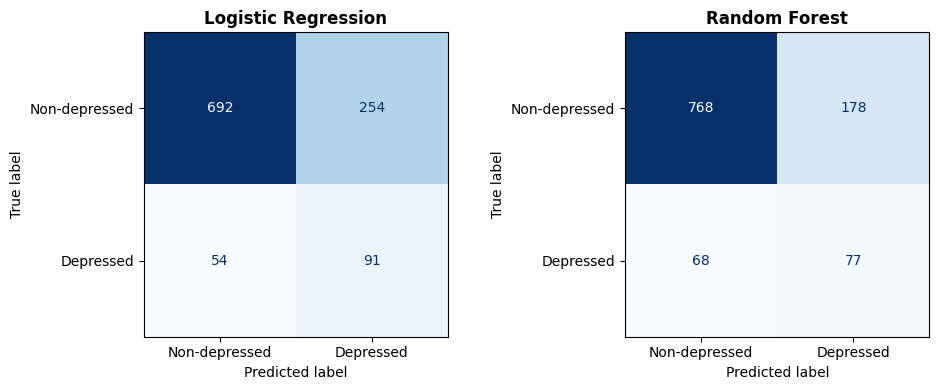

In [ ]:
# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, pred, name in zip(axes, [lr_pred, rf_pred],
                           ["Logistic Regression", "Random Forest"]):
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=["Non-depressed", "Depressed"]).plot(
        ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name, fontweight="bold")

plt.tight_layout()
plt.savefig("fig_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 8. Model Interpretation — Permutation Importance


In [ ]:
# Labelling map for easier interpretation of variables

label_map = {
    "age":                          "Age",
    "sex":                          "Female sex",
    "household_size":               "Household size",
    "income_poverty_ratio":         "Income-to-poverty ratio",
    "health_insurance":             "Health insurance",
    "food_security":                "Food insecurity",
    "bmi":                          "BMI",
    "heavy_drinking_hx":            "Heavy drinking history",
    "diabetes":                     "Diabetes",
    "asthma":                       "Asthma",
    "anaemia_treatment":            "Anaemia treatment",
    "arthritis":                    "Arthritis",
    "heart_failure":                "Heart failure",
    "heart_attack":                 "Heart attack",
    "stroke":                       "Stroke",
    "liver_condition":              "Liver condition",
    "thyroid_problem":              "Thyroid problem",
    "copd":                         "COPD",
    "marital_status_3.0":           "Never Married",
    "employment_status_3.0":        "Looking for work",
    "employment_status_4.0":        "Not working",
    "sleep_weekday_short":          "Short weekday sleep",
    "sleep_weekend_short":          "Short weekend sleep",
    "sedentary_cat_moderate":       "Moderate sedentary behaviour",
    "sedentary_cat_very_high":      "Very high sedentary behaviour",
    "ltpa_cat_sufficiently_active": "Sufficient physical activity",
    "smoking_status_current_smoker":"Current smoker",
    "smoking_ecig_cat_ecig_only":   "E-cigarette only",
    "smoking_ecig_cat_dual_user":   "Dual smoker/e-cigarette user",
    "alcohol_cat_frequent":         "Frequent alcohol use",
}


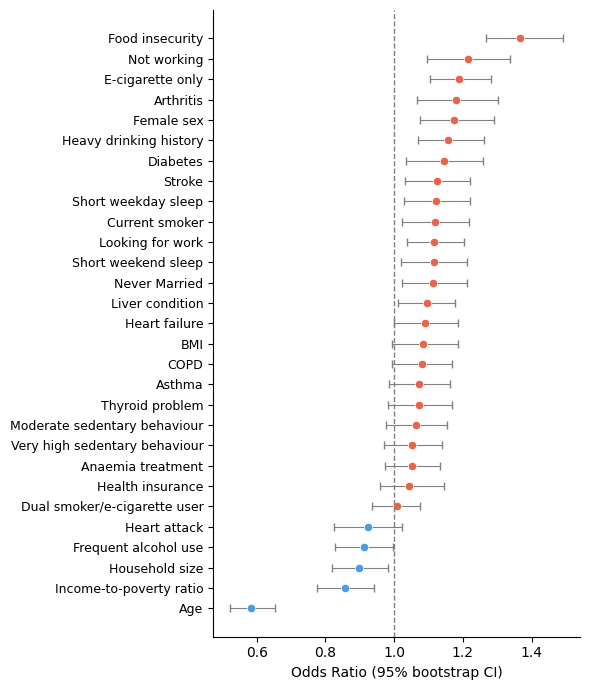

In [ ]:
#  Logistic Regression odds ratios with bootstrap CIs

# Bootstrap CIs for odds ratios
n_boot = 1000
rng    = np.random.RandomState(42)
X_arr  = X_train_sc.values
y_arr  = y_train.values
boot_coefs = []

for _ in range(n_boot):
    idx = rng.choice(len(y_arr), len(y_arr), replace=True)
    m   = LogisticRegression(C=best_lr.C, class_weight="balanced",
                              max_iter=5000, random_state=42)
    m.fit(X_arr[idx], y_arr[idx])
    boot_coefs.append(np.exp(m.coef_[0]))

boot_coefs = np.array(boot_coefs)
or_lower   = np.percentile(boot_coefs, 2.5,  axis=0)
or_upper   = np.percentile(boot_coefs, 97.5, axis=0)

# Build dataframe and sort BEFORE computing xerr
or_df = pd.DataFrame({
    "Feature":  selected_features,
    "OR":       np.exp(best_lr.coef_[0]),
    "OR_lower": or_lower,
    "OR_upper": or_upper,
}).sort_values("OR", ascending=True).reset_index(drop=True)

or_df["Label"]      = or_df["Feature"].map(label_map).fillna(or_df["Feature"])
or_df["xerr_left"]  = or_df["OR"] - or_df["OR_lower"]
or_df["xerr_right"] = or_df["OR_upper"] - or_df["OR"]

# Plot
fig, ax = plt.subplots(figsize=(6, 7))
y_pos   = np.arange(len(or_df))
colours = ["#E8654C" if o > 1 else "#4C9BE8" for o in or_df["OR"]]

# Error bars first
ax.errorbar(or_df["OR"], y_pos,
            xerr=[or_df["xerr_left"], or_df["xerr_right"]],
            fmt="none", color="grey", capsize=3, linewidth=0.8)

# Coloured dots on top
for i, (or_val, col) in enumerate(zip(or_df["OR"], colours)):
    ax.plot(or_val, i, "o", color=col, markersize=6,
            markeredgecolor="white", markeredgewidth=0.5)

ax.axvline(1, color="grey", linestyle="--", linewidth=1)
ax.set_yticks(y_pos)
ax.set_yticklabels(or_df["Label"], fontsize=9)
ax.set_xlabel("Odds Ratio (95% bootstrap CI)")
sns.despine()
plt.tight_layout()
plt.savefig("fig_lr_odds_ratios.png", dpi=150, bbox_inches="tight")
plt.show()



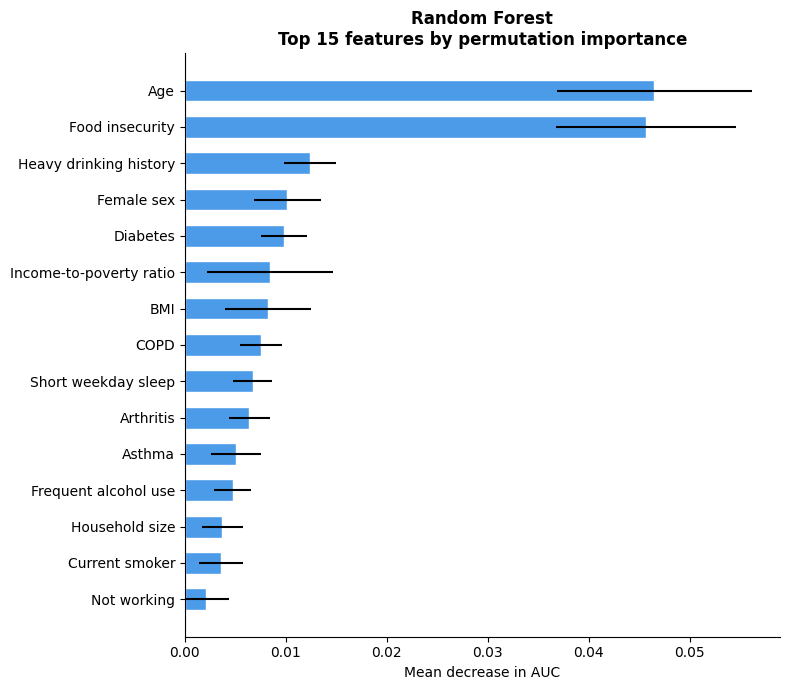

In [ ]:
# Permutation importance - Random Forest

# 30 repeats used to stabilise importance estimates (error bars show SD across repeats)
perm = permutation_importance(
    best_rf, X_test_sc, y_test,
    scoring="roc_auc",
    n_repeats=30,  # number of times each feature is shuffled
    random_state=42,
    n_jobs=-1
)
# Sort by mean importance descending, take top 15
sorted_idx = perm.importances_mean.argsort()[::-1][:15]
feat_names = [selected_features[i] for i in sorted_idx]
feat_labels = [label_map.get(f, f) for f in feat_names]  # map to readable labels
means      = perm.importances_mean[sorted_idx]
stds       = perm.importances_std[sorted_idx]

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(feat_labels[::-1], means[::-1], xerr=stds[::-1],  # changed feat_names to feat_labels
        color="#4C9BE8", edgecolor="white", height=0.6)
ax.set_xlabel("Mean decrease in AUC")
ax.set_title("Random Forest\nTop 15 features by permutation importance",
             fontweight="bold")
ax.axvline(0, color="grey", linewidth=0.8, linestyle="--") # reference line at 0
ax.set_xlim(left=0)
sns.despine()
plt.tight_layout()
plt.savefig("fig_permutation_importance.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 9. Fairness Analysis


In [ ]:
# Prepare fairness subgroup labels

fair_test  = fair_test.reset_index(drop=True)
y_test_arr = y_test.reset_index(drop=True)

# Age groups
fair_test["age_group"] = pd.cut(
    fair_test["age"],
    bins=[18, 35, 50, 65, 120],
    labels=["18-35", "36-50", "51-65", "65+"]
)

# Sex labels
fair_test["sex_label"] = fair_test["sex"].map({0: "Male", 1: "Female"})


In [ ]:
#  Subgroup metrics function
def subgroup_metrics(model, X_test_sc, y_test_arr, subgroup_col, fair_df, min_n=20):
    X_arr = X_test_sc.values if hasattr(X_test_sc, "values") else X_test_sc
    y_arr = np.array(y_test_arr)
    rows  = []

    for group in fair_df[subgroup_col].dropna().unique():
        mask = (fair_df[subgroup_col] == group).values
        if mask.sum() < min_n:
            continue
        X_g, y_g = X_arr[mask], y_arr[mask]
        if len(np.unique(y_g)) < 2:
            continue

        y_pred  = model.predict(X_g)
        y_proba = model.predict_proba(X_g)[:, 1]

        rows.append({
            "Subgroup":    group,
            "n":           int(mask.sum()),
            "Depressed n": int(y_g.sum()),
            "AUC":         round(roc_auc_score(y_g, y_proba), 3),
            "Sensitivity": round(recall_score(y_g, y_pred, zero_division=0), 3),
            "Specificity": round(recall_score(y_g, y_pred, pos_label=0, zero_division=0), 3),
            "Precision":   round(precision_score(y_g, y_pred, zero_division=0), 3),
            "F1":          round(f1_score(y_g, y_pred, zero_division=0), 3),
        })

    return pd.DataFrame(rows).set_index("Subgroup")

In [ ]:
# Fairness Analysis across age and sex

for stratifier, label in [("sex_label", "Sex"),
                           ("age_group", "Age group")]:
    lr_sg = subgroup_metrics(best_lr, X_test_sc, y_test_arr, stratifier, fair_test)
    rf_sg = subgroup_metrics(best_rf, X_test_sc, y_test_arr, stratifier, fair_test)

    combined = lr_sg.add_prefix("LR_").join(rf_sg.add_prefix("RF_")) # merge models side by side
    print(f"\nFairness by {label}:")
    print(combined.to_string())
    combined.to_csv(f"table_fairness_{stratifier}.csv") # save for reporting


Fairness by Sex:
          LR_n  LR_Depressed n  LR_AUC  LR_Sensitivity  LR_Specificity  LR_Precision  LR_F1  RF_n  RF_Depressed n  RF_AUC  RF_Sensitivity  RF_Specificity  RF_Precision  RF_F1
Subgroup                                                                                                                                                                      
Male       471              47   0.752           0.574           0.774         0.220  0.318   471              47   0.747           0.532           0.835         0.263  0.352
Female     620              98   0.752           0.653           0.697         0.288  0.400   620              98   0.760           0.531           0.793         0.325  0.403

Fairness by Age group:
          LR_n  LR_Depressed n  LR_AUC  LR_Sensitivity  LR_Specificity  LR_Precision  LR_F1  RF_n  RF_Depressed n  RF_AUC  RF_Sensitivity  RF_Specificity  RF_Precision  RF_F1
Subgroup                                                                           